# C-Store physical-layout POC analysis

## tl;dr

Both the generated mock and the privately extracted raw rows support the paper's focused claim for narrow analytical queries: a column layout avoids stepping through unused wide payloads, while a matching sorted projection turns a range scan into binary-search bounds. The raw-database section uses redacted aggregate output only.

## Context & Methods

The experiment compares custom row/column × sorted/unsorted binary files. SQLite is never used for a timed query. Each result is the median of nine warm-cache runs after two warmups, and every query result is checked across all four layouts.

### Key Assumptions

- These Python/NumPy timings illustrate physical-layout behavior, not a production DBMS speed claim.
- The raw-database artifact contains aggregate timings and sizes only; row values and labels are excluded.
- Gzip size is an identical generic compression baseline, not C-Store's native compressed execution.

## Data

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

root = Path.cwd()
demo = root / "demo_results"
synthetic = json.loads((demo / "cstore_poc_summary.json").read_text())
raw = json.loads((demo / "raw_db_summary_sanitized.json").read_text())

pd.DataFrame([
    {"dataset": "Synthetic mock", "rows": synthetic["data_profile"]["row_count"], "privacy": "No source row values"},
    {"dataset": "Provided raw rows", "rows": raw["data_profile"]["row_count"], "privacy": "Redacted aggregates only"},
])

,dataset,rows,privacy
0,Synthetic mock,85478,No source row values
1,Provided raw rows,85478,Redacted aggregates only


## Results

In [2]:
def latency_table(summary):
    frame = pd.DataFrame(summary["benchmark_results"])
    return frame.pivot(index="query", columns="layout", values="median_ms").round(3)

print("Synthetic median latency (ms)")
display(latency_table(synthetic))
print("Raw-row median latency (ms; labels redacted)")
display(latency_table(raw))

Synthetic median latency (ms)


layout,column_sorted,column_unsorted,row_sorted,row_unsorted
query,,,,
payload_bytes_for_status,0.380,0.406,30.228,27.378
status_count,0.065,0.063,31.606,27.131
topic_time_count,0.129,0.144,0.190,32.917


Raw-row median latency (ms; labels redacted)


layout,column_sorted,column_unsorted,row_sorted,row_unsorted
query,,,,
payload_bytes_for_status,0.387,0.398,28.040,26.797
status_count,0.105,0.067,30.271,31.178
topic_time_count,0.168,0.145,0.238,30.304


Synthetic result


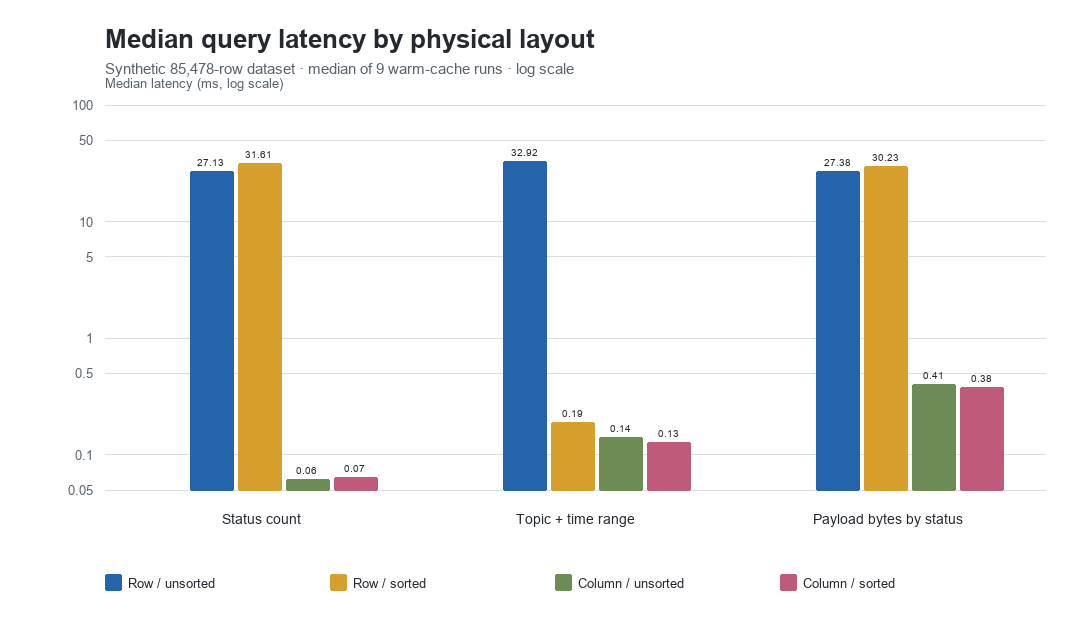

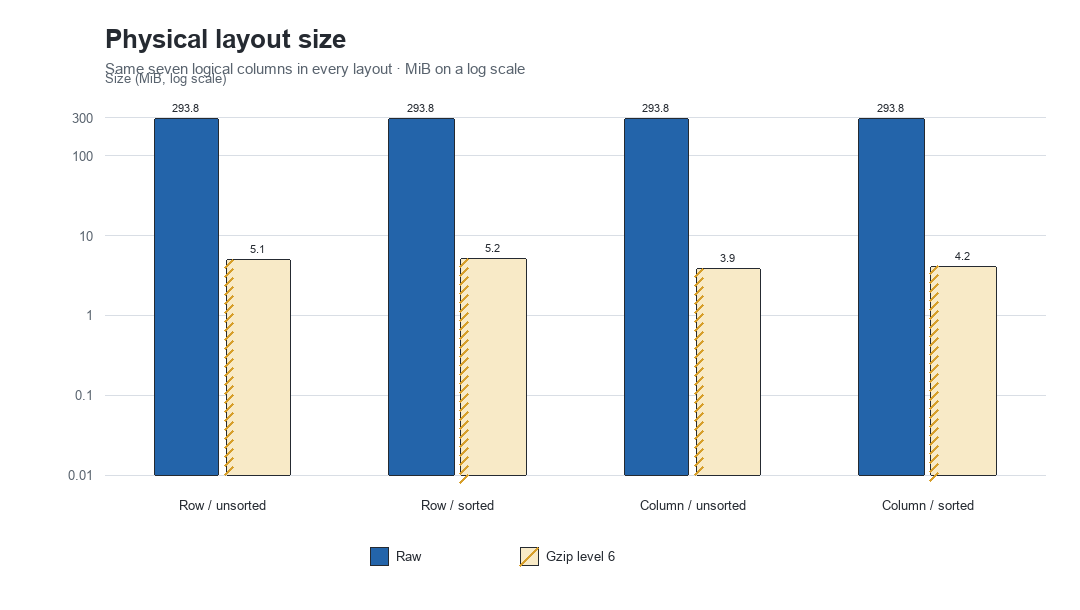

Provided raw rows — aggregate output only


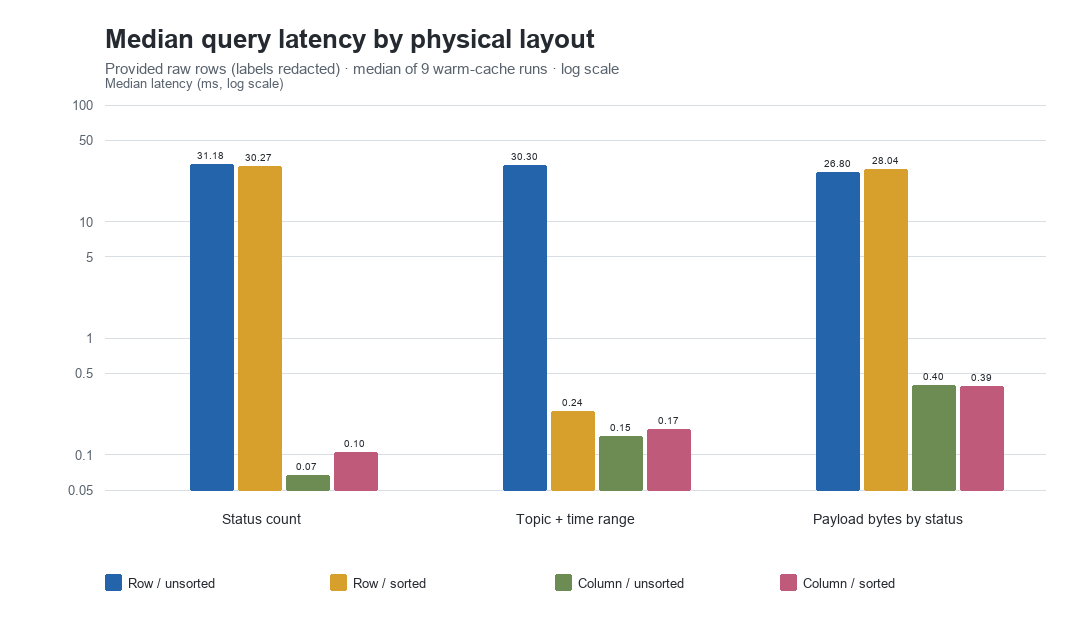

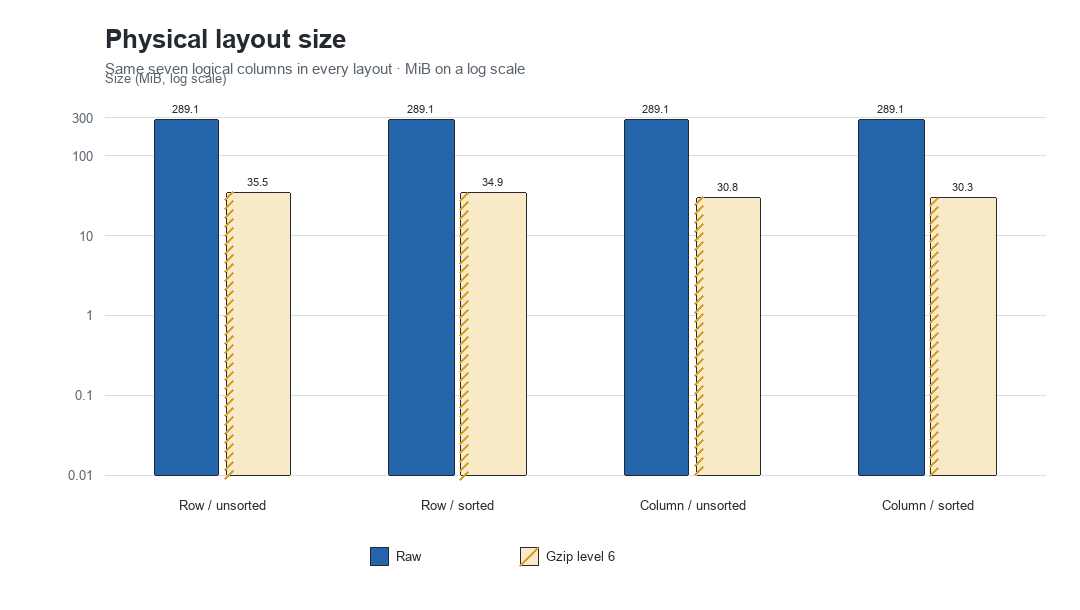

In [3]:
print("Synthetic result")
display(Image(filename=str(demo / "benchmark_latency.png")))
display(Image(filename=str(demo / "layout_size.png")))
print("Provided raw rows — aggregate output only")
display(Image(filename=str(demo / "raw_db_benchmark_latency.png")))
display(Image(filename=str(demo / "raw_db_layout_size.png")))

In [4]:
def speedups(summary):
    values = {(row["layout"], row["query"]): row["median_ms"] for row in summary["benchmark_results"]}
    return pd.Series({
        "column status scan vs row": values[("row_unsorted", "status_count")] / values[("column_unsorted", "status_count")],
        "column topic/time scan vs row": values[("row_unsorted", "topic_time_count")] / values[("column_unsorted", "topic_time_count")],
        "sorted row topic/time vs unsorted row": values[("row_unsorted", "topic_time_count")] / values[("row_sorted", "topic_time_count")],
        "column payload-length aggregate vs row": values[("row_unsorted", "payload_bytes_for_status")] / values[("column_unsorted", "payload_bytes_for_status")],
    }).round(1)

pd.DataFrame({"Synthetic speedup (x)": speedups(synthetic), "Raw-row speedup (x)": speedups(raw)})

,Synthetic speedup (x),Raw-row speedup (x)
column status scan vs row,433.8,466.8
column topic/time scan vs row,229.2,208.9
sorted row topic/time vs unsorted row,173.4,127.1
column payload-length aggregate vs row,67.4,67.3


## Takeaways

1. Use a column-oriented read path when production work is dominated by scans and aggregates over a few fields.
2. Add a `(topic_name, time)` projection only for a measured recurring predicate; sorting is not universally beneficial.
3. Keep a row-oriented or reconstruction path for writes and wide-record retrieval, which this POC does not benchmark.
4. Treat the absolute speedups as implementation-specific; the robust finding is the large reduction in touched bytes and the consistent direction across mock and raw-derived runs.